In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'sklearn'

In [17]:
df=pd.read_csv(r"C:\Users\dheju\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [18]:
print(df.head(10))
print(df.tail(10))
print("Shape of dataset:",df.shape)
print("Column names:",df.columns.tolist())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [19]:
print("Data info:",df.info())
print("Summary:",df.describe())
print("Missing values:",df.isnull().sum().sum())
print("Duplicated values:",df.duplicated().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'],errors="coerce")

In [22]:
numerical=df.select_dtypes(include=['int64','float64']).columns
print(numerical)
categorical=df.select_dtypes(include=['str']).columns
print(categorical)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')


In [23]:
for col in numerical:
    df[col]=df[col].fillna(df[col].median())

In [24]:
for col in categorical:
    df[col]=df[col].fillna(df[col].mode()[0])

In [25]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [12]:
print(df["Partner"].unique())
print(df["Dependents"].unique())
print(df["Churn"].unique())
#encoding-label encoding,onehot-encoding

label_col=['Partner','Dependents','Churn']
for col in label_col:
    df[col]=df[col].map({'Yes':1,'No':0})

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [13]:
df[["Partner", "Dependents", "Churn"]].head()

,Partner,Dependents,Churn
0,1,0,0
1,0,0,0
2,0,0,1
3,0,0,0
4,0,0,1


In [14]:
one_hot_col=[
    "gender",
    "Contract",
    "PaymentMethod",
    "InternetService"
]
df=pd.get_dummies(df,columns=one_hot_col,drop_first=True,dtype=int)

In [15]:
print(df.head())

   customerID  SeniorCitizen  Partner  Dependents  tenure PhoneService  \
0  7590-VHVEG              0        1           0       1           No   
1  5575-GNVDE              0        0           0      34          Yes   
2  3668-QPYBK              0        0           0       2          Yes   
3  7795-CFOCW              0        0           0      45           No   
4  9237-HQITU              0        0           0       2          Yes   

      MultipleLines OnlineSecurity OnlineBackup DeviceProtection  ...  \
0  No phone service             No          Yes               No  ...   
1                No            Yes           No              Yes  ...   
2                No            Yes          Yes               No  ...   
3  No phone service            Yes           No              Yes  ...   
4                No             No           No               No  ...   

  TotalCharges Churn gender_Male Contract_One year  Contract_Two year  \
0        29.85     0           0           

In [20]:
scale=StandardScaler()
df[['tenure','MonthlyCharges','TotalCharges']]=scale.fit_transform(df[['tenure','MonthlyCharges','TotalCharges']])

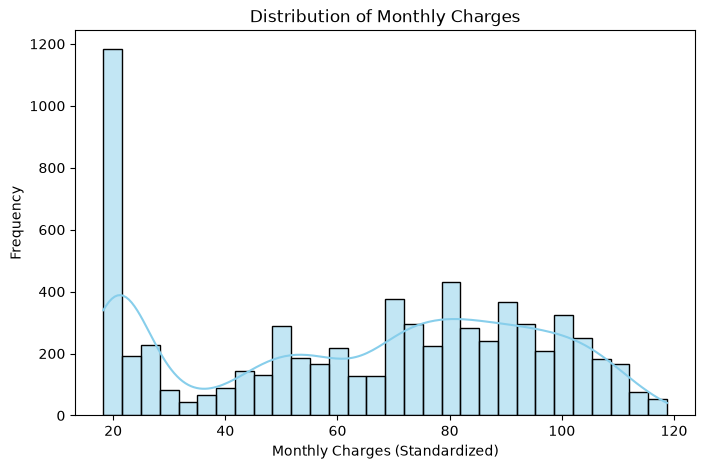

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges (Standardized)")
plt.ylabel("Frequency")


plt.show()

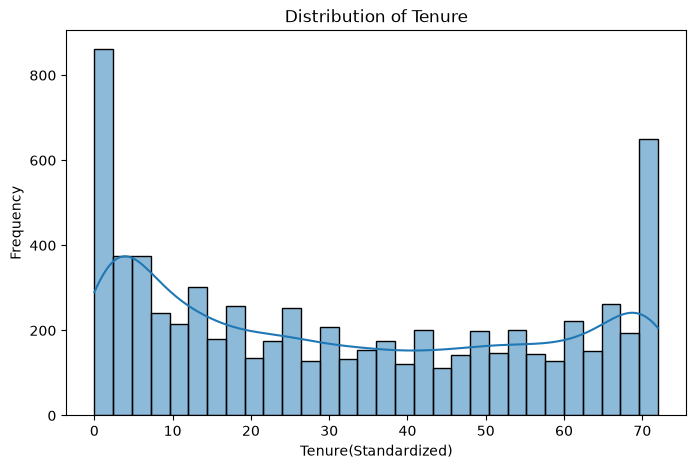

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'],bins=30,kde=True)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure(Standardized)")
plt.ylabel("Frequency")
plt.show()


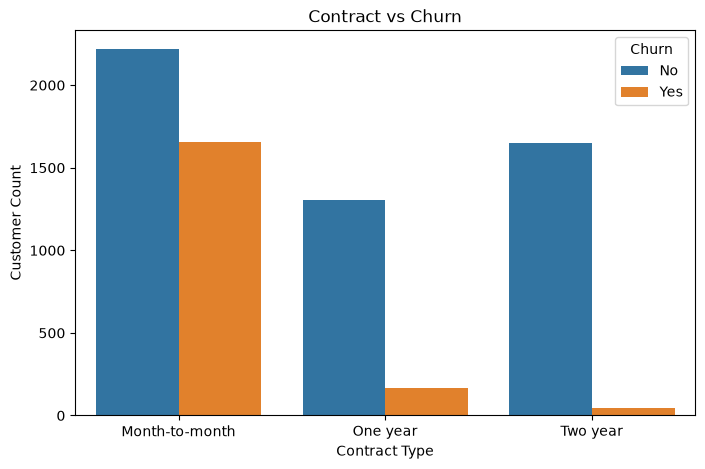

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")

plt.show()

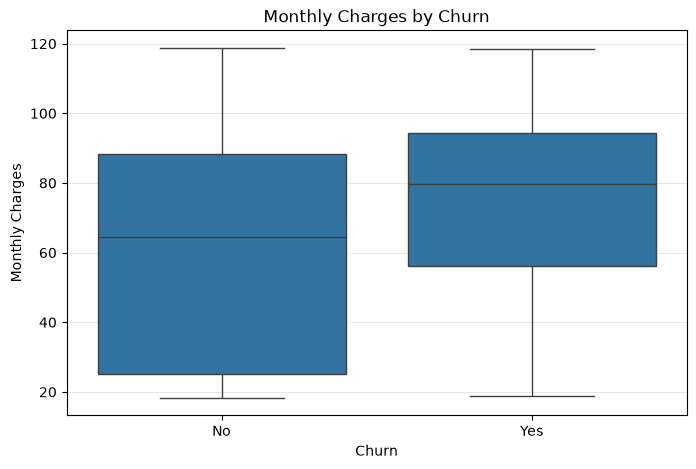

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [1]:
correlation=df.corr(numeric_only=True)
sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


NameError: name 'df' is not defined